Логическая регрессия + TF-IDF

In [1]:
# Импорты
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
from configs.config import PROCESSED_DIR, MODEL_DIR

import mlflow

from src.utils.mlflow_utils import setup_mlflow
from src.utils.mlflow_safe import safe_run

mlflow = setup_mlflow("sentiment_analysis")

c:\Users\korobochka_sahara\dpo\dpo-ai\project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow URI: sqlite:///C:\Users\korobochka_sahara\dpo\dpo-ai\project\artifacts\mlflow\mlflow.db


In [2]:
# Данные
train = pd.read_csv(PROCESSED_DIR / "train_ml.csv")
test = pd.read_csv(PROCESSED_DIR / "test_ml.csv")

label_encoder = LabelEncoder()

train["label"] = label_encoder.fit_transform(
    train["sentiment"]
)

test["label"] = label_encoder.transform(
    test["sentiment"]
)

In [3]:
vectorizer = joblib.load(MODEL_DIR / "tfidf_vectorizer.pkl")

X_train = vectorizer.transform(train["processed_text"])
X_test = vectorizer.transform(test["processed_text"])

y_train = train["label"]
y_test = test["label"]

In [ ]:
# Эксперимент
model = LogisticRegression(
    C = 2.0,
    max_iter=1000,
    class_weight="balanced"
)

In [16]:
with safe_run("logreg_tfidf"):

    # training
    model.fit(X_train, y_train)

    # prediction
    preds = model.predict(X_test)

    # metrics
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)

    # logging MLflow
    mlflow.log_params({
        "model": "LogisticRegression",
        "vectorizer": "TF-IDF",
        "ngram_range": "(1,2)",
        "max_features": 10000,
        "class_weight": "balanced",
        "max_iter": 1000,
        "C": model.C,
        "max_iter": model.max_iter,
        "class_weight": model.class_weight,
        "solver": model.solver,
        "random_state": model.random_state
    })

    mlflow.log_metrics({
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    })

    mlflow.sklearn.log_model(model, "model")

    print(f"Done. accuracy={acc:.4f}, f1={f1:.4f}")

2026/05/15 17:01:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 17:01:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Done. accuracy=0.8894, f1=0.8926


In [17]:
import mlflow

runs = mlflow.search_runs()

runs[[
    "run_id",
    "metrics.accuracy",
    "metrics.f1",
    "params.model"
]].sort_values("metrics.f1", ascending=False)


,run_id,metrics.accuracy,metrics.f1,params.model
4,c7d74e8afb7545fc9978aa5b1fa67f32,0.908132,0.909396,DistilBERT
0,bbd2bf464fc04cb6af41481db6685e40,0.889378,0.892642,LogisticRegression
1,d92cc56f739a4ffa9b5e7d970707cbb0,0.889378,0.892642,LogisticRegression
3,4b8d96e974fc44fcacb9b2784b78668f,0.888878,0.892115,LogisticRegression
2,40ef9d3e936c40528dccb4e2d45c0140,0.888578,0.891908,LogisticRegression
5,5783a87cd577450a9e6349eda1dd59e8,NaN,NaN,DistilBERT


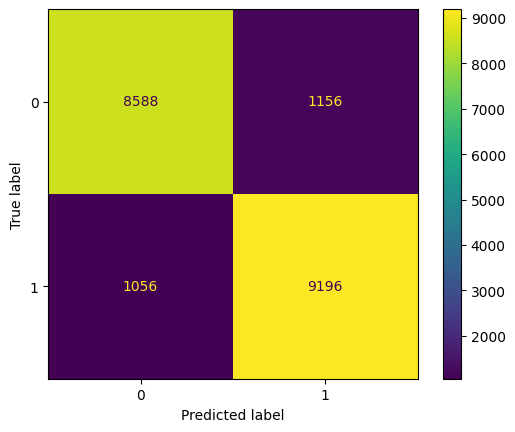

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from configs.config import ARTIFACTS_DIR

ConfusionMatrixDisplay(cm).plot()
plt.show()
cm_path = f"{ARTIFACTS_DIR}/models/confusion_matrix_logreg.png"
plt.savefig(cm_path)
plt.close()